In [28]:
import numpy as np
import scipy
import math
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import random as rand
import part1

In [29]:
# Load data
img1 = np.array(Image.open('./part1/320.jpg')) # image1
img2 = np.array(Image.open('./part1/test_images/330.jpg')) # image2

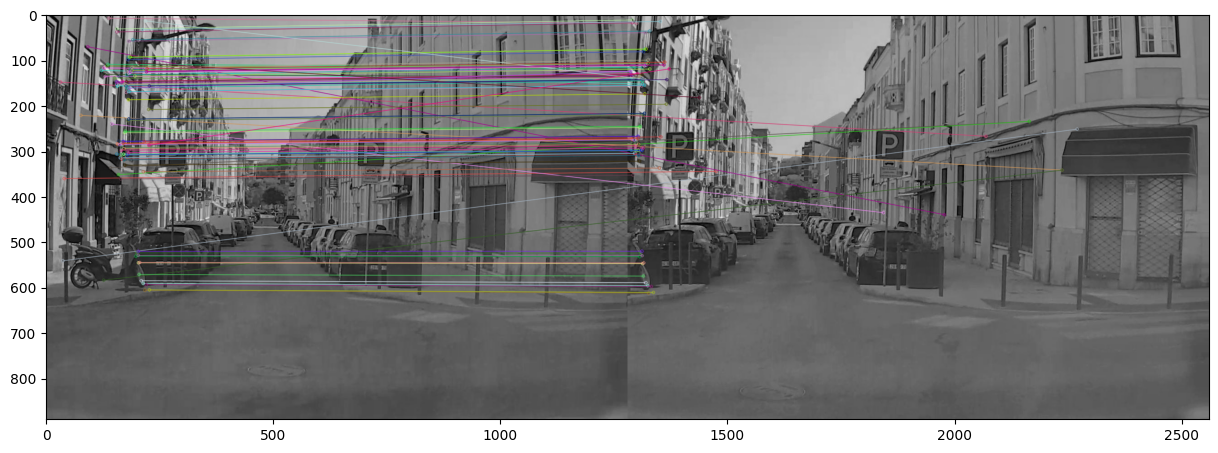

Total points: 1637
Most Inliers found: 465
Homography from RANSAC: 
 [[ 1.40157456e-02 -1.26646685e-03 -4.91175435e-01]
 [-1.45488183e-03  1.55254030e-02  8.70608345e-01]
 [-3.30174423e-06 -1.88946411e-06  1.86172571e-02]]
Obtained after 705 iterations
Homography from all points: 
 [[ 8.20983966e-01 -4.45235728e-02 -5.39784914e+01]
 [-5.93714720e-02  8.99453571e-01  2.92531213e+01]
 [-1.33016843e-04 -4.87173892e-05  1.00000000e+00]]


In [38]:
### PART 1 ###
## Feature Detection and Matching
# Feature Detection
sift = cv2.SIFT_create()

# Convert RGB images into Grey images for SIFT
img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Detect keypoints and compute keypoint descriptors on both images
keypoints_img1, descriptors_img1 = sift.detectAndCompute(img1_gray, None)
keypoints_img2, descriptors_img2 = sift.detectAndCompute(img2_gray, None)


# Draw the keypoints on both images
img1_with_keypoints = cv2.drawKeypoints(img1_gray, keypoints_img1, img1_gray)
img2_with_keypoints = cv2.drawKeypoints(img2_gray, keypoints_img2, img2_gray)

# Save the images
cv2.imwrite("sift_320.jpg", img1_with_keypoints)
cv2.imwrite("sift_330.jpg", img2_with_keypoints)

# Feature Matching
bf = cv2.BFMatcher()
matches = bf.knnMatch(descriptors_img1, descriptors_img2, k=2)

good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append([m])

img3 = cv2.drawMatchesKnn(img1_gray, keypoints_img1, img2_gray, keypoints_img2, good_matches[:100], None, flags=2)

fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(111)
ax.imshow(img3)
plt.show()

## Outlier Removal with RANSAC

points_img1 = []
points_img2 = []

for match in good_matches:
    m = match[0] # because good_matches is a list of lists of only one element
    p1 = keypoints_img1[m.queryIdx].pt
    p2 = keypoints_img2[m.trainIdx].pt
    points_img1.append(p1)
    points_img2.append(p2)

pts1 = np.float32(points_img1)
pts2 = np.float32(points_img2)
homogeneous_pts1 = np.vstack([pts1.T, np.ones((1, pts1.shape[0]))])

n = 4
P = 0.99
p = 0.5
max_iterations = 10000
iteration = 0
most_inliers = -math.inf
best_H = np.array([])

while iteration < max_iterations:
    random_indexes = np.random.choice(len(pts1), 4, replace=False)
    rand_pts1 = pts1[random_indexes]
    rand_pts2 = pts2[random_indexes]

    A = []
    for [x1, y1], [x2, y2] in zip(rand_pts1, rand_pts2):
        A.append([x1, y1, 1, 0, 0, 0, -x2*x1, -x2*y1, -x2])
        A.append([0, 0, 0, x1, y1, 1, -y2*x1, -y2*y1, -y2])
    
    A = np.array(A)
    
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    H = Vt[-1].reshape(3, 3)
    
    # Project points of image1 into image2 using H (obtained from the previous step)
    new_pts1 = H.dot(homogeneous_pts1)
    new_pts1 = np.column_stack((new_pts1[0] / new_pts1[2] , new_pts1[1] / new_pts1[2]))
    
    # Calculate error, count inliers and keep H if it's the best so far
    diff = new_pts1 - pts2
    distances = np.linalg.norm(diff, axis=1)
    inliers = np.sum(distances < 3)
    if inliers > most_inliers:
        most_inliers = inliers
        best_H = H
        p = inliers / len(pts1)
        p = max(0.001, min(0.99, p))
        if (1 - p**n) > 0 and np.log(1 - p**n) != 0:
            max_iterations = int(np.log(1 - P) / np.log(1 - p**n))

    iteration += 1

print(f'Total points: {len(pts1)}')
print(f'Most Inliers found: {most_inliers}')
print("Homography from RANSAC: \n", best_H)
print(f'Obtained after {iteration} iterations')

correct_pts1 = best_H.dot(homogeneous_pts1)
correct_pts1 = np.column_stack((correct_pts1[0] / correct_pts1[2] , correct_pts1[1] / correct_pts1[2]))
correct_matched_pts1 = []
correct_matched_pts2 = []
for [x1, y1], [corr_x1, corr_y1], [x2, y2] in zip(pts1, correct_pts1, pts2):
    distance = math.sqrt((x2 - corr_x1) ** 2 + (y2 - corr_y1) ** 2)
    if distance < 5: # better decide what is an inlier/outlier
        correct_matched_pts1.append([x1, y1])
        correct_matched_pts2.append([x2, y2])

## Normalization
def normalize_points(pts):
    pts = np.asarray(pts)

    centroid = np.mean(pts, axis=0)
    pts_shifted = pts - centroid

    mean_dist = np.mean(np.sqrt(np.sum(pts_shifted**2, axis=1)))
    scale = np.sqrt(2) / mean_dist

    T = np.array([
        [scale, 0, -scale * centroid[0]],
        [0, scale, -scale * centroid[1]],
        [0, 0, 1]
    ])

    # Convert to homogeneous coordinates
    pts_h = np.hstack([pts, np.ones((pts.shape[0], 1))])
    pts_norm_h = (T @ pts_h.T).T

    return pts_norm_h[:, :2], T

pts1_norm, T1 = normalize_points(correct_matched_pts1)
pts2_norm, T2 = normalize_points(correct_matched_pts2)

## Homography Estimation via Least Squares
A = []
for [x1, y1], [x2, y2] in zip(pts1_norm, pts2_norm):
    A.append([x1, y1, 1, 0, 0, 0, -x2*x1, -x2*y1, -x2])
    A.append([0, 0, 0, x1, y1, 1, -y2*x1, -y2*y1, -y2])

A = np.array(A)

U, S, Vt = np.linalg.svd(A, full_matrices=False)
H_norm = Vt[-1].reshape(3, 3)

## De-normalize Homography

H = np.linalg.inv(T2) @ H_norm @ T1
H = H / H[2, 2]

print("Homography from all points: \n", H) 



## Outcome: Tracking and rectifying a planar document in real time under camera motion

In [4]:
### PART 2 — RGB-D EXTENSION ###

h, w = img1.shape[:2]

# Approximate camera intrinsics
fx = fy = 0.9 * w
cx = w / 2
cy = h / 2

K = np.array([
    [fx, 0, cx],
    [0, fy, cy],
    [0,  0,  1]
])

depth1 = np.load("./part1/320_depth.npy").astype(np.float32)

# 3D Point Extraction

def backproject(pts_2d, depth_map, K):
    fx, fy = K[0,0], K[1,1]
    cx, cy = K[0,2], K[1,2]

    pts_3d = []

    for (u, v) in pts_2d:
        u, v = int(round(u)), int(round(v))

        if u < 0 or v < 0 or u >= depth_map.shape[1] or v >= depth_map.shape[0]:
            continue

        z = depth_map[v, u]
        if z <= 0 or np.isnan(z):
            continue

        x = (u - cx) * z / fx
        y = (v - cy) * z / fy
        pts_3d.append([x, y, z])

    return np.array(pts_3d)

pts3d = backproject(correct_matched_pts1, depth1, K)
print("Extracted 3D points:", pts3d.shape)

# Homography Refinement

pts1_np = np.array(correct_matched_pts1, dtype=np.float32)
pts2_np = np.array(correct_matched_pts2, dtype=np.float32)

H_depth_refined, _ = cv2.findHomography(pts1_np, pts2_np, method=0)
print("Depth-refined homography:\n", H_depth_refined)

print("Number of valid 3D points:", pts3d.shape[0])

Extracted 3D points: (930, 3)
Depth-refined homography:
 [[ 1.02473058e+00 -1.96838227e-03 -1.39071238e+02]
 [-6.23520406e-03  1.03775978e+00 -1.38828158e+01]
 [ 1.19659656e-05  1.67453810e-05  1.00000000e+00]]
Number of valid 3D points: 930
